In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

In [3]:
import gymnasium as gym
import flappy_bird_gymnasium

In [4]:
from gymnasium.wrappers import (
    GrayscaleObservation,
    ResizeObservation,
    FrameStackObservation,
)

In [5]:
# Custom wrapper to return RGB screen frames as observations
class PixelWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        # FlappyBird render output shape is (512, 288, 3)
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(512, 288, 3), dtype=np.uint8
        )

    def observation(self, observation):
        return self.env.render()

In [6]:
# 1. Create base environments with rendering enabled
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
eval_env = gym.make("FlappyBird-v0", render_mode="rgb_array")

# 2. Wrap environments to yield pixel frames
env = PixelWrapper(env)
eval_env = PixelWrapper(eval_env)

# 3. Apply standard Gymnasium image preprocessing wrappers
env = GrayscaleObservation(env)
env = ResizeObservation(env, (84, 84))
env = FrameStackObservation(env, stack_size=4)

eval_env = GrayscaleObservation(eval_env)
eval_env = ResizeObservation(eval_env, (84, 84))
eval_env = FrameStackObservation(eval_env, stack_size=4)

state, _ = env.reset()
print("Observation shape:", state.shape)  # Output: (4, 84, 84)

Observation shape: (4, 84, 84)


/home/eclat/miniconda3/envs/rl/lib/python3.14/site-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [7]:
s_size = env.observation_space.shape[0]
a_size = env.action_space.n

In [8]:
print(f"State space size: {s_size}")
print(f"Action space size: {a_size}")

State space size: 4
Action space size: 2


In [9]:
print("_____OBSERVATION SPACE_____ \n")
print("The State Space is: ", s_size)
print("Sample observation", env.observation_space.sample())  # Get a random observation

_____OBSERVATION SPACE_____ 

The State Space is:  4
Sample observation [[[ 73 225  74 ... 254  86 114]
  [251  61 106 ...  74 228  61]
  [126 165  63 ... 248 168  36]
  ...
  [194 189 212 ... 103   7  35]
  [234  10 109 ... 162 135  50]
  [204 140 153 ...  38 146 117]]

 [[189  78 195 ... 224  53  67]
  [126  16  68 ... 125  50 193]
  [230 117 114 ... 110  47  23]
  ...
  [244 152 215 ...  44 197 137]
  [ 30 200 164 ...  30 166 173]
  [ 19 177  65 ... 156  59 107]]

 [[203 172 171 ... 132 105 189]
  [234  44 213 ... 152  21  78]
  [123  36 138 ...  55 124 161]
  ...
  [163  45  90 ... 205 114 165]
  [168 208 244 ... 156 247 184]
  [223 104  66 ... 147 163 116]]

 [[242 198 148 ...  51 169 111]
  [233  21   8 ...  65 203 189]
  [127 167  73 ... 245  19  11]
  ...
  [ 10 154  87 ...  64  24 105]
  [ 49 250  38 ...  78 209  55]
  [ 23  59 110 ... 237  74   9]]]


In [10]:
print("\n _____ACTION SPACE_____ \n")
print("The Action Space is: ", a_size)
print("Action Space Sample", env.action_space.sample())  # Take a random action


 _____ACTION SPACE_____ 

The Action Space is:  2
Action Space Sample 1


### Observation Space (Pixel-Based)

Instead of the 12-feature vector, the agent receives stacked raw screen frames processed through a Gym wrapper pipeline.

* **Observation Shape:** `(4, 84, 84)` — `(Frame Stack, Height, Width)`
* **Data Type:** Grayscale pixel values ranging from `0` to `255` (`uint8`)

**Preprocessing Pipeline**
* **Frame Extraction:** Captures raw screen renders `(512, 288, 3)` directly from the environment using `render_mode="rgb_array"`.
* **Grayscale Conversion:** Converts RGB images down to a single channel (`GrayscaleObservation`).
* **Spatial Downsampling:** Resizes resolution down to $84 \times 84$ pixels to minimize network parameters (`ResizeObservation`).
* **Frame Stacking:** Stacks `4` consecutive frames (`FrameStackObservation`) to enable the CNN to perceive velocity, falling acceleration, and pipe movement speed.

In [11]:
class CNNPolicy(nn.Module):
    def __init__(self, in_channels=4, a_size=2):
        super(CNNPolicy, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )
        # intermediate hidden linear layer (512 units)
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, a_size)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return F.softmax(x, dim=1)

    def act(self, state):
        # Convert LazyFrames array, scale pixels to [0, 1], and add batch dimension
        state_tensor = torch.from_numpy(np.array(state)).float().unsqueeze(0).to(device) / 255.0
        probs = self.forward(state_tensor).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

### Define the hyperparameters
Because this environment is more complex.  
Especially for the hidden size, we need more neurons.

In [12]:
# Define environment metadata variables
env_id = "FlappyBird-v0"
s_size = env.observation_space.shape
a_size = env.action_space.n

In [13]:
hyperparameters = {
    "h_size": 64,
    "n_training_episodes": 5000,
    "n_evaluation_episodes": 10,
    "max_t": 10000,
    "gamma": 0.99,
    "lr": 1e-4,
    "env_id": env_id,
    "state_space": s_size,
    "action_space": a_size,
}

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [15]:
print(device)

cuda:0


In [16]:
# Create policy and place it to the device
policy = CNNPolicy(in_channels=4, a_size=a_size).to(device)

optimizer = optim.Adam(policy.parameters(), lr=hyperparameters["lr"])

In [17]:
def reinforce(policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    scores_deque = deque(maxlen=100)
    scores = []

    for i_episode in range(1, n_training_episodes + 1):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset()

        # Step 1: Collect trajectory
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break

        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Step 2: Compute discounted returns (G_t) starting from end of episode
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)

        for t in range(n_steps)[::-1]:
            disc_return_t = returns[0] if len(returns) > 0 else 0
            returns.appendleft(gamma * disc_return_t + rewards[t])

        # Normalize returns for numeric stability
        eps = np.finfo(np.float32).eps.item()
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + eps)

        # Step 3: Compute policy loss
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return)
        policy_loss = torch.cat(policy_loss).sum()

        # Step 4: Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print(f"Episode {i_episode}\tAverage Score (Last 100): {np.mean(scores_deque):.2f}")

    return scores

In [18]:
scores = reinforce(
    policy,
    optimizer,
    hyperparameters["n_training_episodes"],
    hyperparameters["max_t"],
    hyperparameters["gamma"],
    1000,
)

/home/eclat/miniconda3/envs/rl/lib/python3.14/site-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Episode 1000	Average Score (Last 100): -0.88
Episode 2000	Average Score (Last 100): -0.54
Episode 3000	Average Score (Last 100): -0.44
Episode 4000	Average Score (Last 100): -1.40
Episode 5000	Average Score (Last 100): 0.17


## Plot Rewards

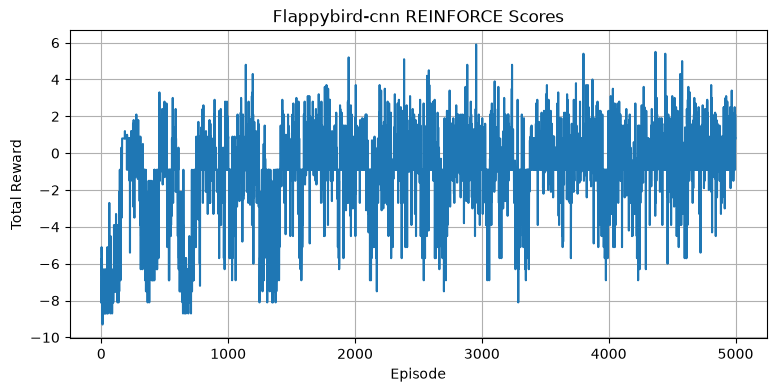

In [19]:
plt.figure(figsize=(9, 4))
plt.plot(scores)
plt.title("Flappybird-cnn REINFORCE Scores")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [20]:
def evaluate_agent(env, max_steps, n_eval_episodes, policy):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param max_steps: Maximum steps per episode
    :param n_eval_episodes: Number of episodes to evaluate the agent
    :param policy: The Reinforce agent
    """
    episode_rewards = []
    for episode in range(n_eval_episodes):
        # Gymnasium reset returns (state, info)
        state, _ = env.reset()
        done = False
        total_rewards_ep = 0

        for step in range(max_steps):
            action, _ = policy.act(state)
            
            # Gymnasium step returns 5 values: state, reward, terminated, truncated, info
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_rewards_ep += reward

            if done:
                break
        episode_rewards.append(total_rewards_ep)
        
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [21]:
evaluate_agent(
    eval_env, hyperparameters["max_t"], hyperparameters["n_evaluation_episodes"], policy
)

/home/eclat/miniconda3/envs/rl/lib/python3.14/site-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


(np.float64(0.2500000000000005), np.float64(2.320021551624035))